In [ ]:
from ultralytics import YOLO
import torch

device = torch.device('cuda')

model = YOLO('yolov8n.pt')

results = model.train(
    data='hrplanes.yaml',
    epochs=5,
    imgsz=640,
    batch=16,
    device=device,
)

engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=hrplanes.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-2, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, 

In [2]:
metrics = model.val(data='hrplanes.yaml', device=device)

print(f"mAP50: {metrics.box.map50:.4f}")
print(f"mAP50-95: {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall: {metrics.box.mr:.4f}")

Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2629.1±1028.7 MB/s, size: 2542.2 KB)
val: Scanning /home/d.golomolzin/AI_labs/3lab/HRPlanes/val/labels.cache... 616 images, 6 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 617/617 112.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 3.0it/s 13.0s0.2s
                   all        617       3279      0.972      0.964      0.985      0.764
Speed: 0.7ms preprocess, 2.2ms inference, 0.0ms loss, 4.6ms postprocess per image
Results saved to /home/d.golomolzin/AI_labs/3lab/runs/detect/val
mAP50: 0.9852
mAP50-95: 0.7638
Precision: 0.9718
Recall: 0.9643


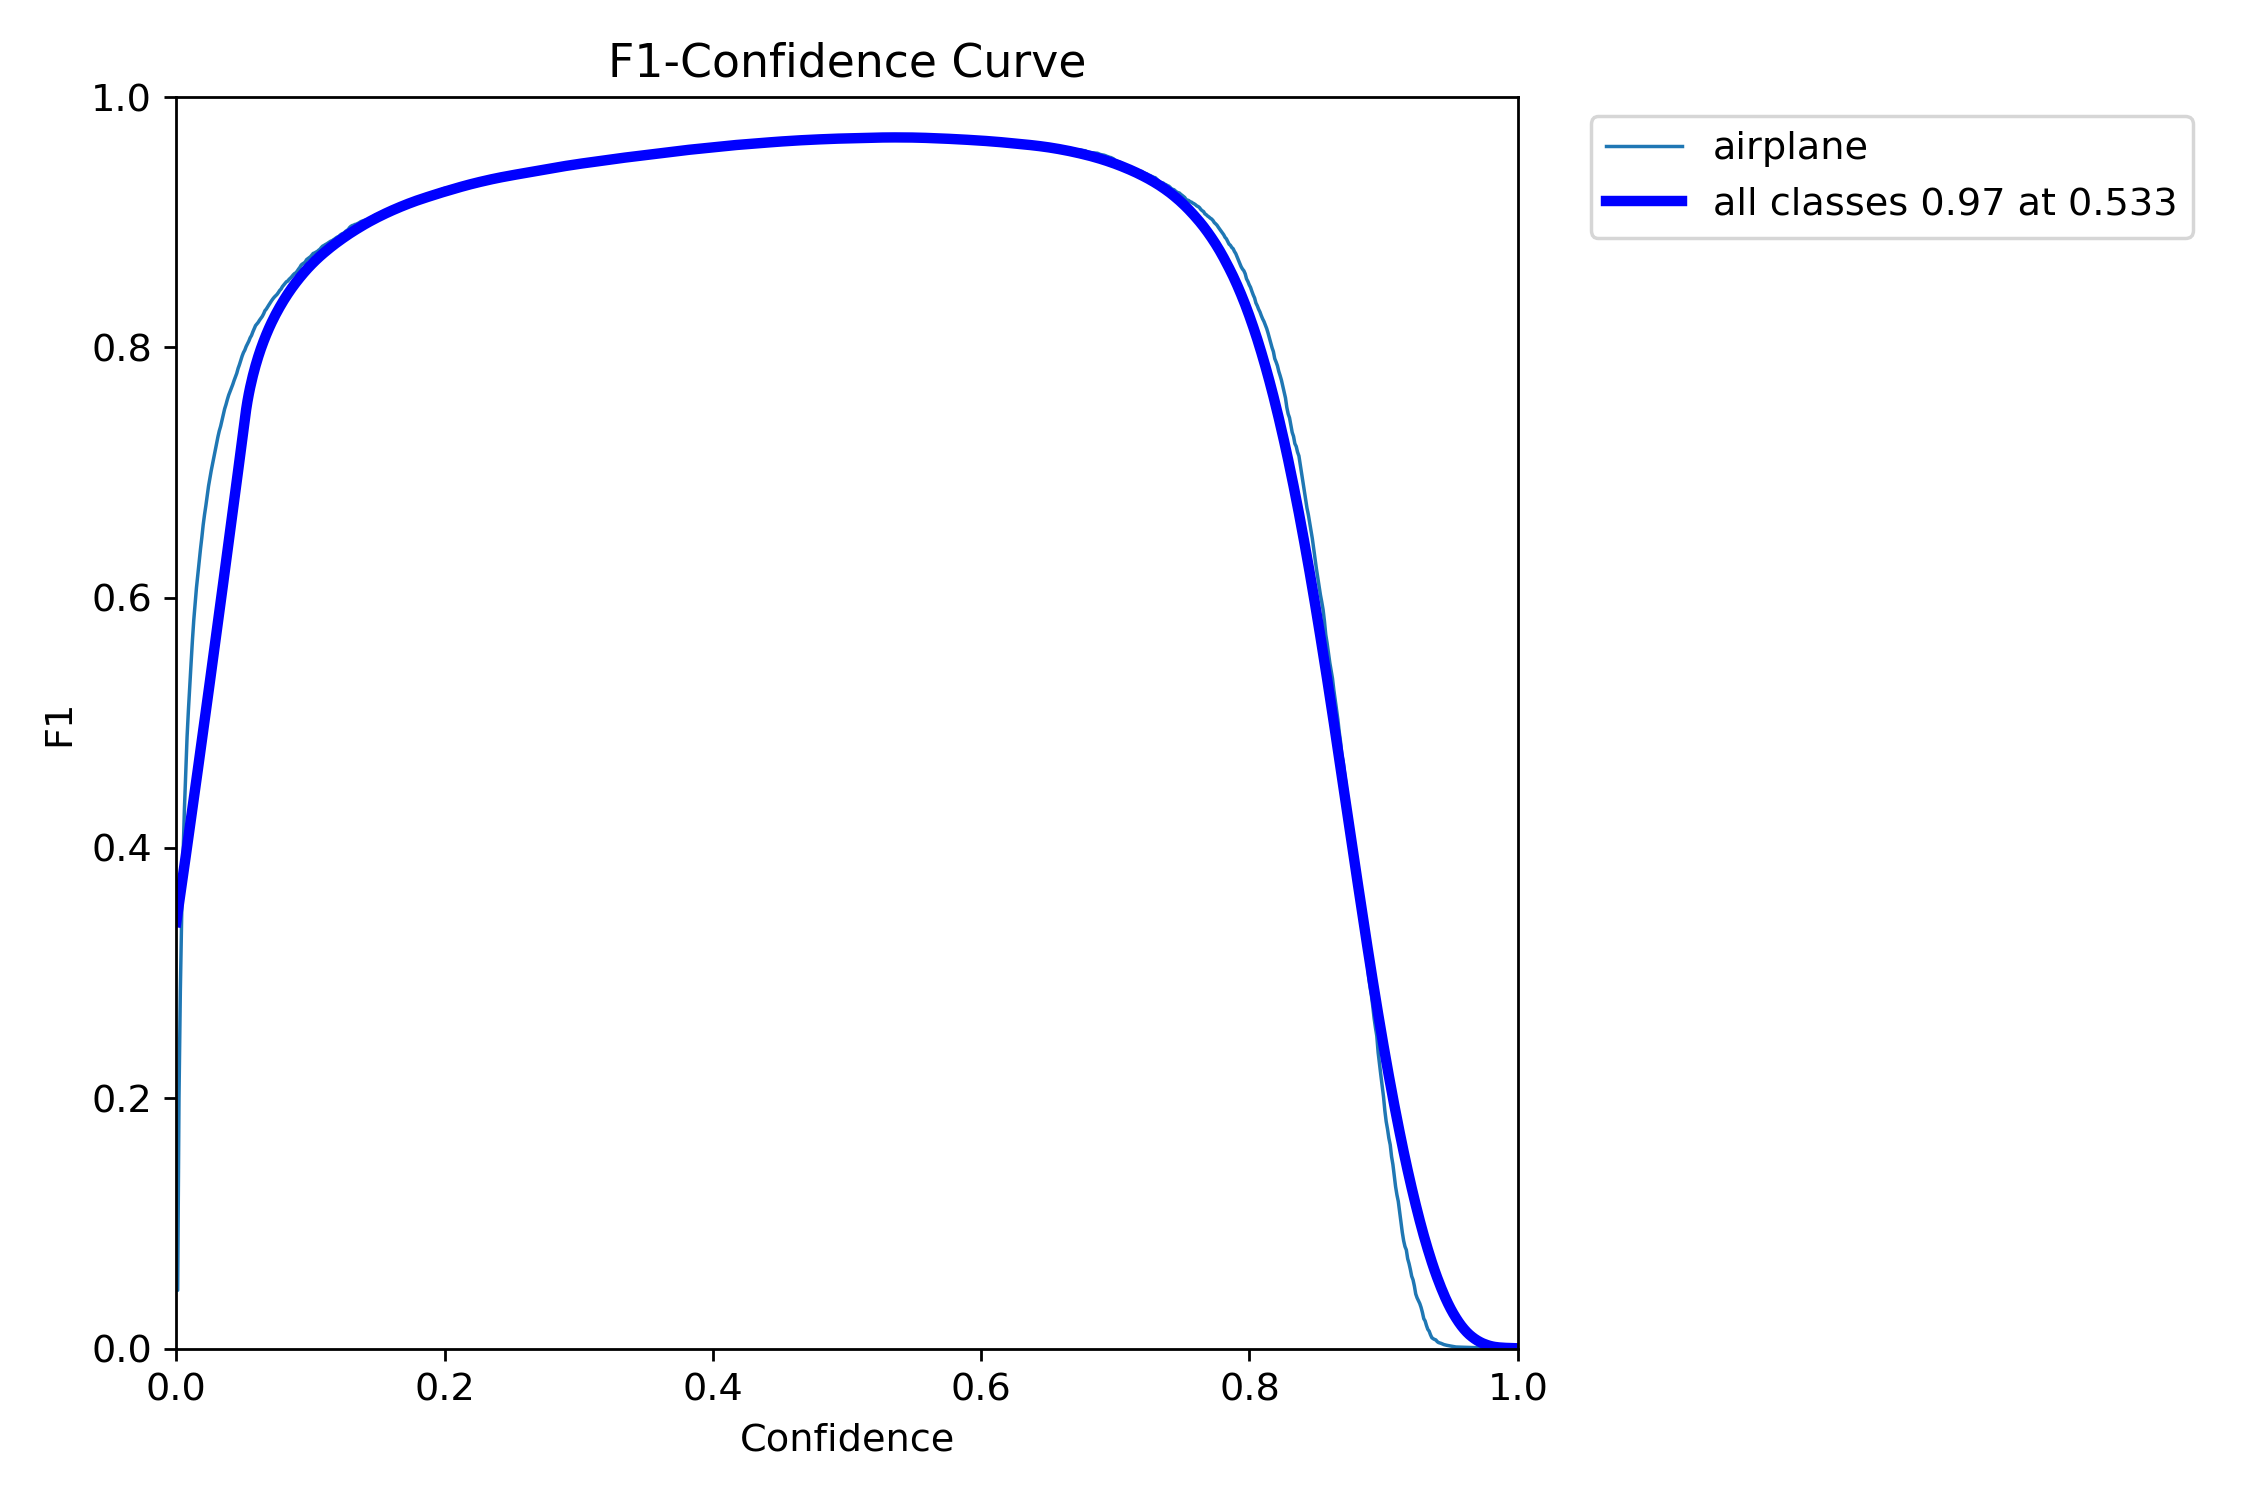

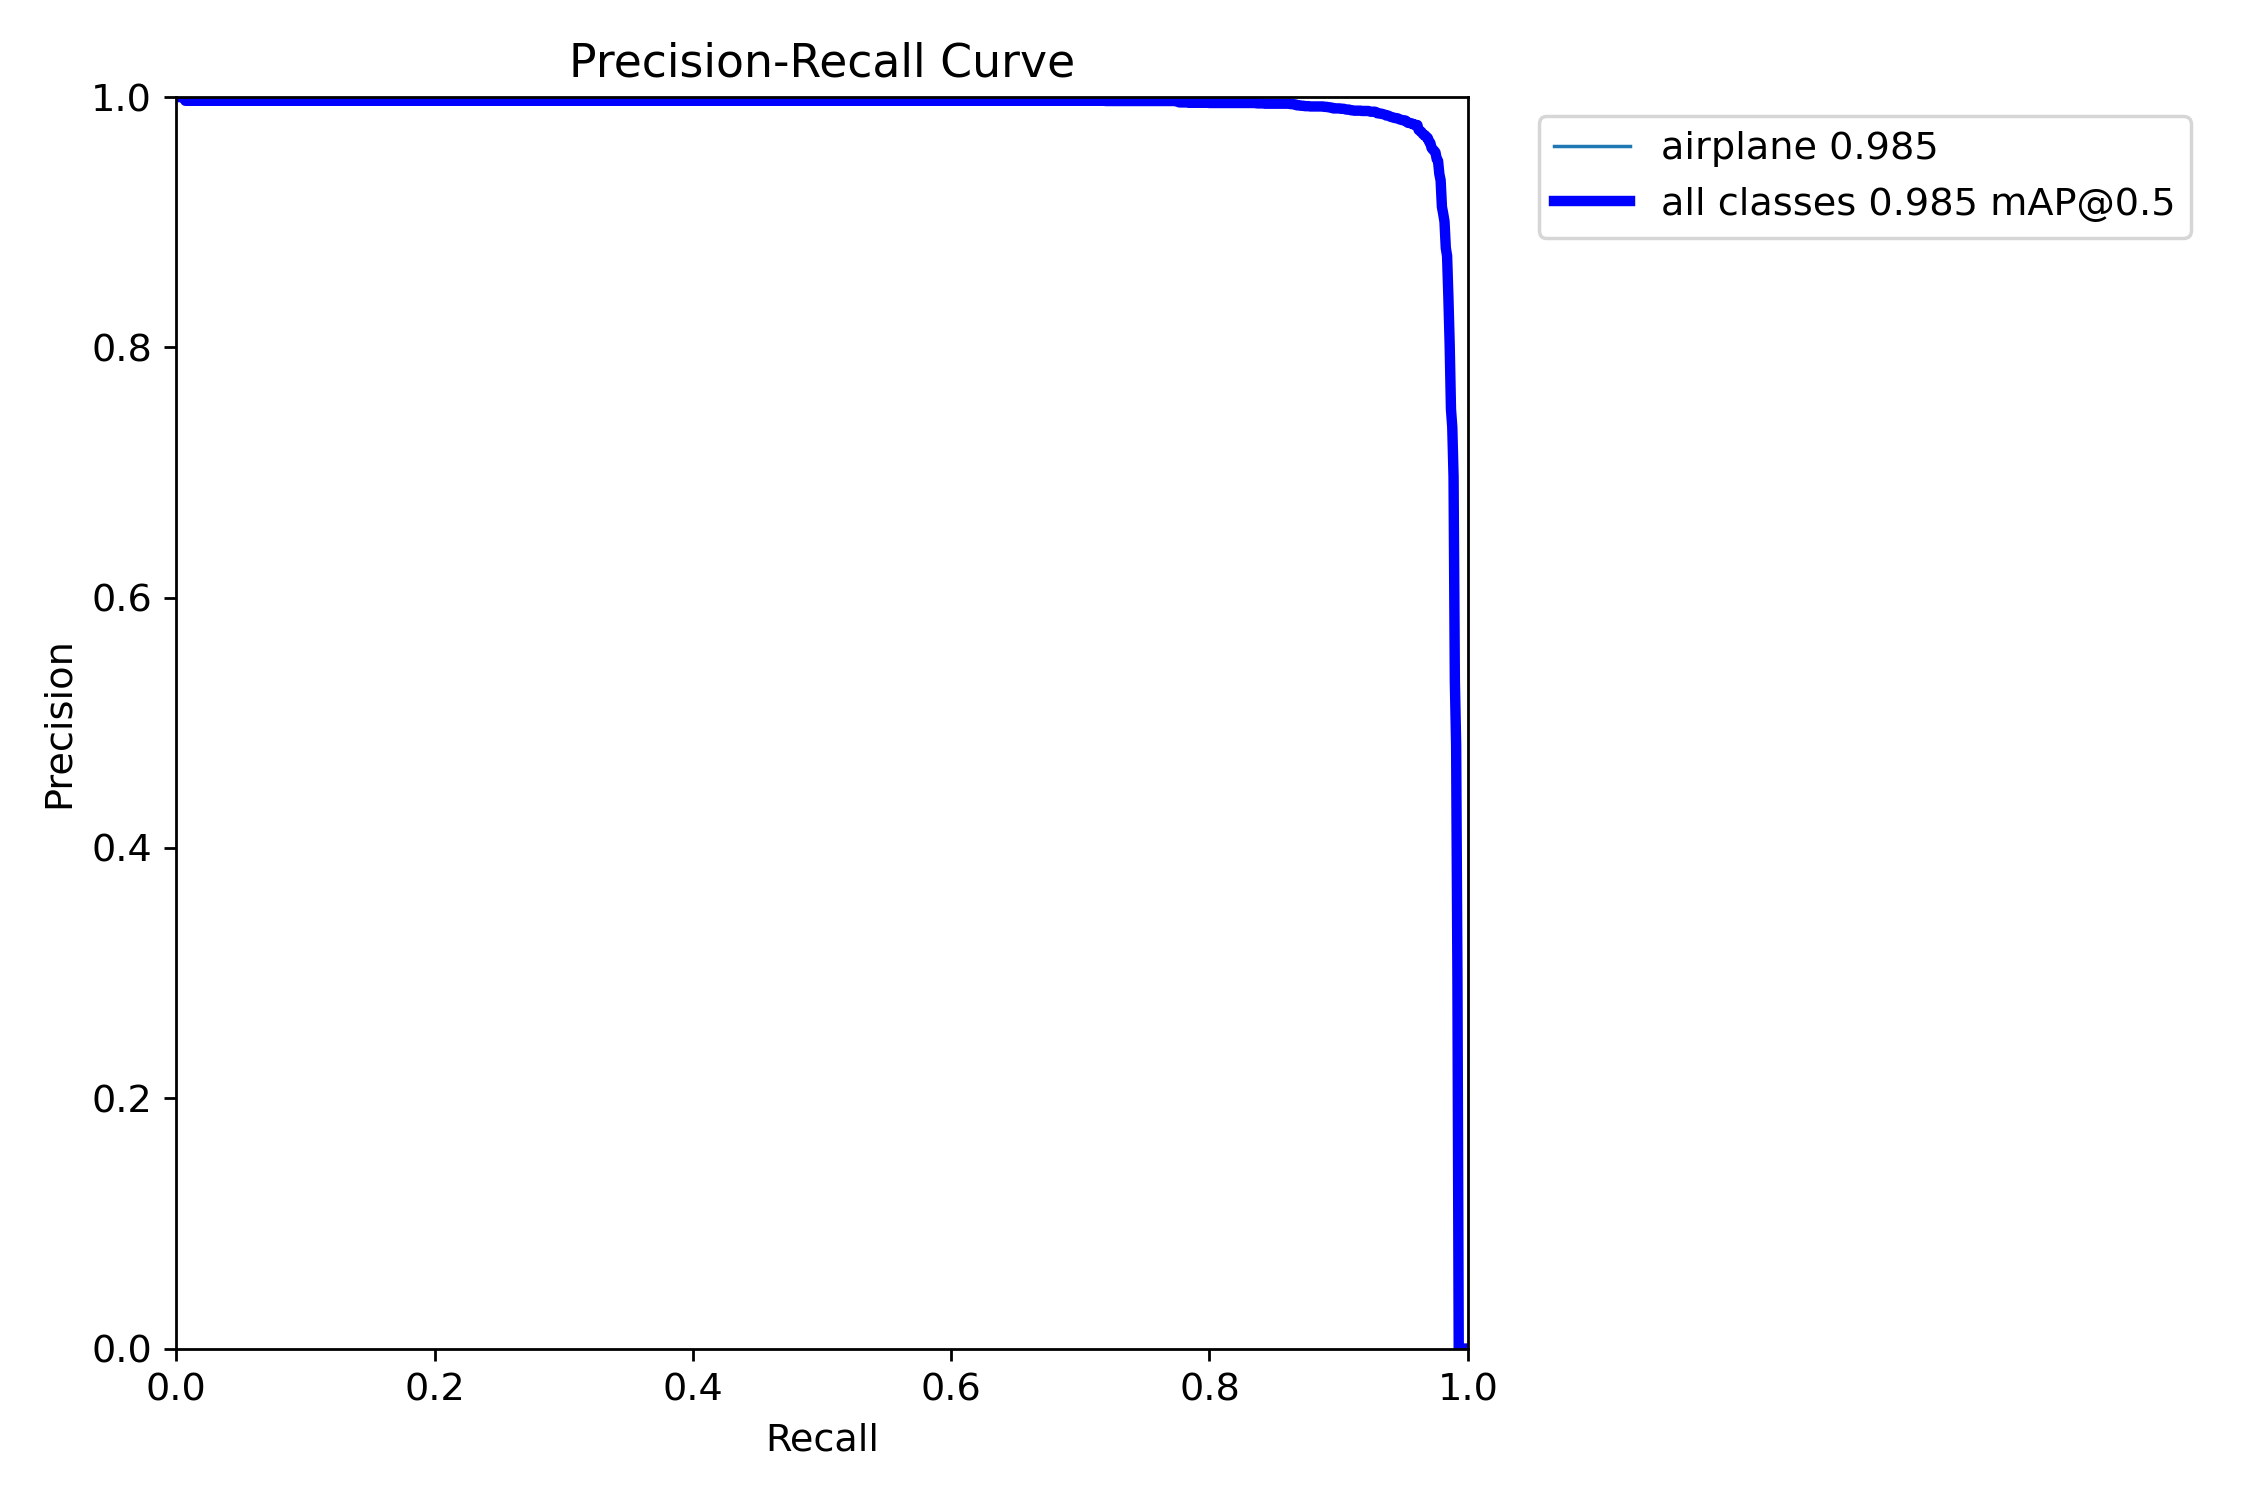

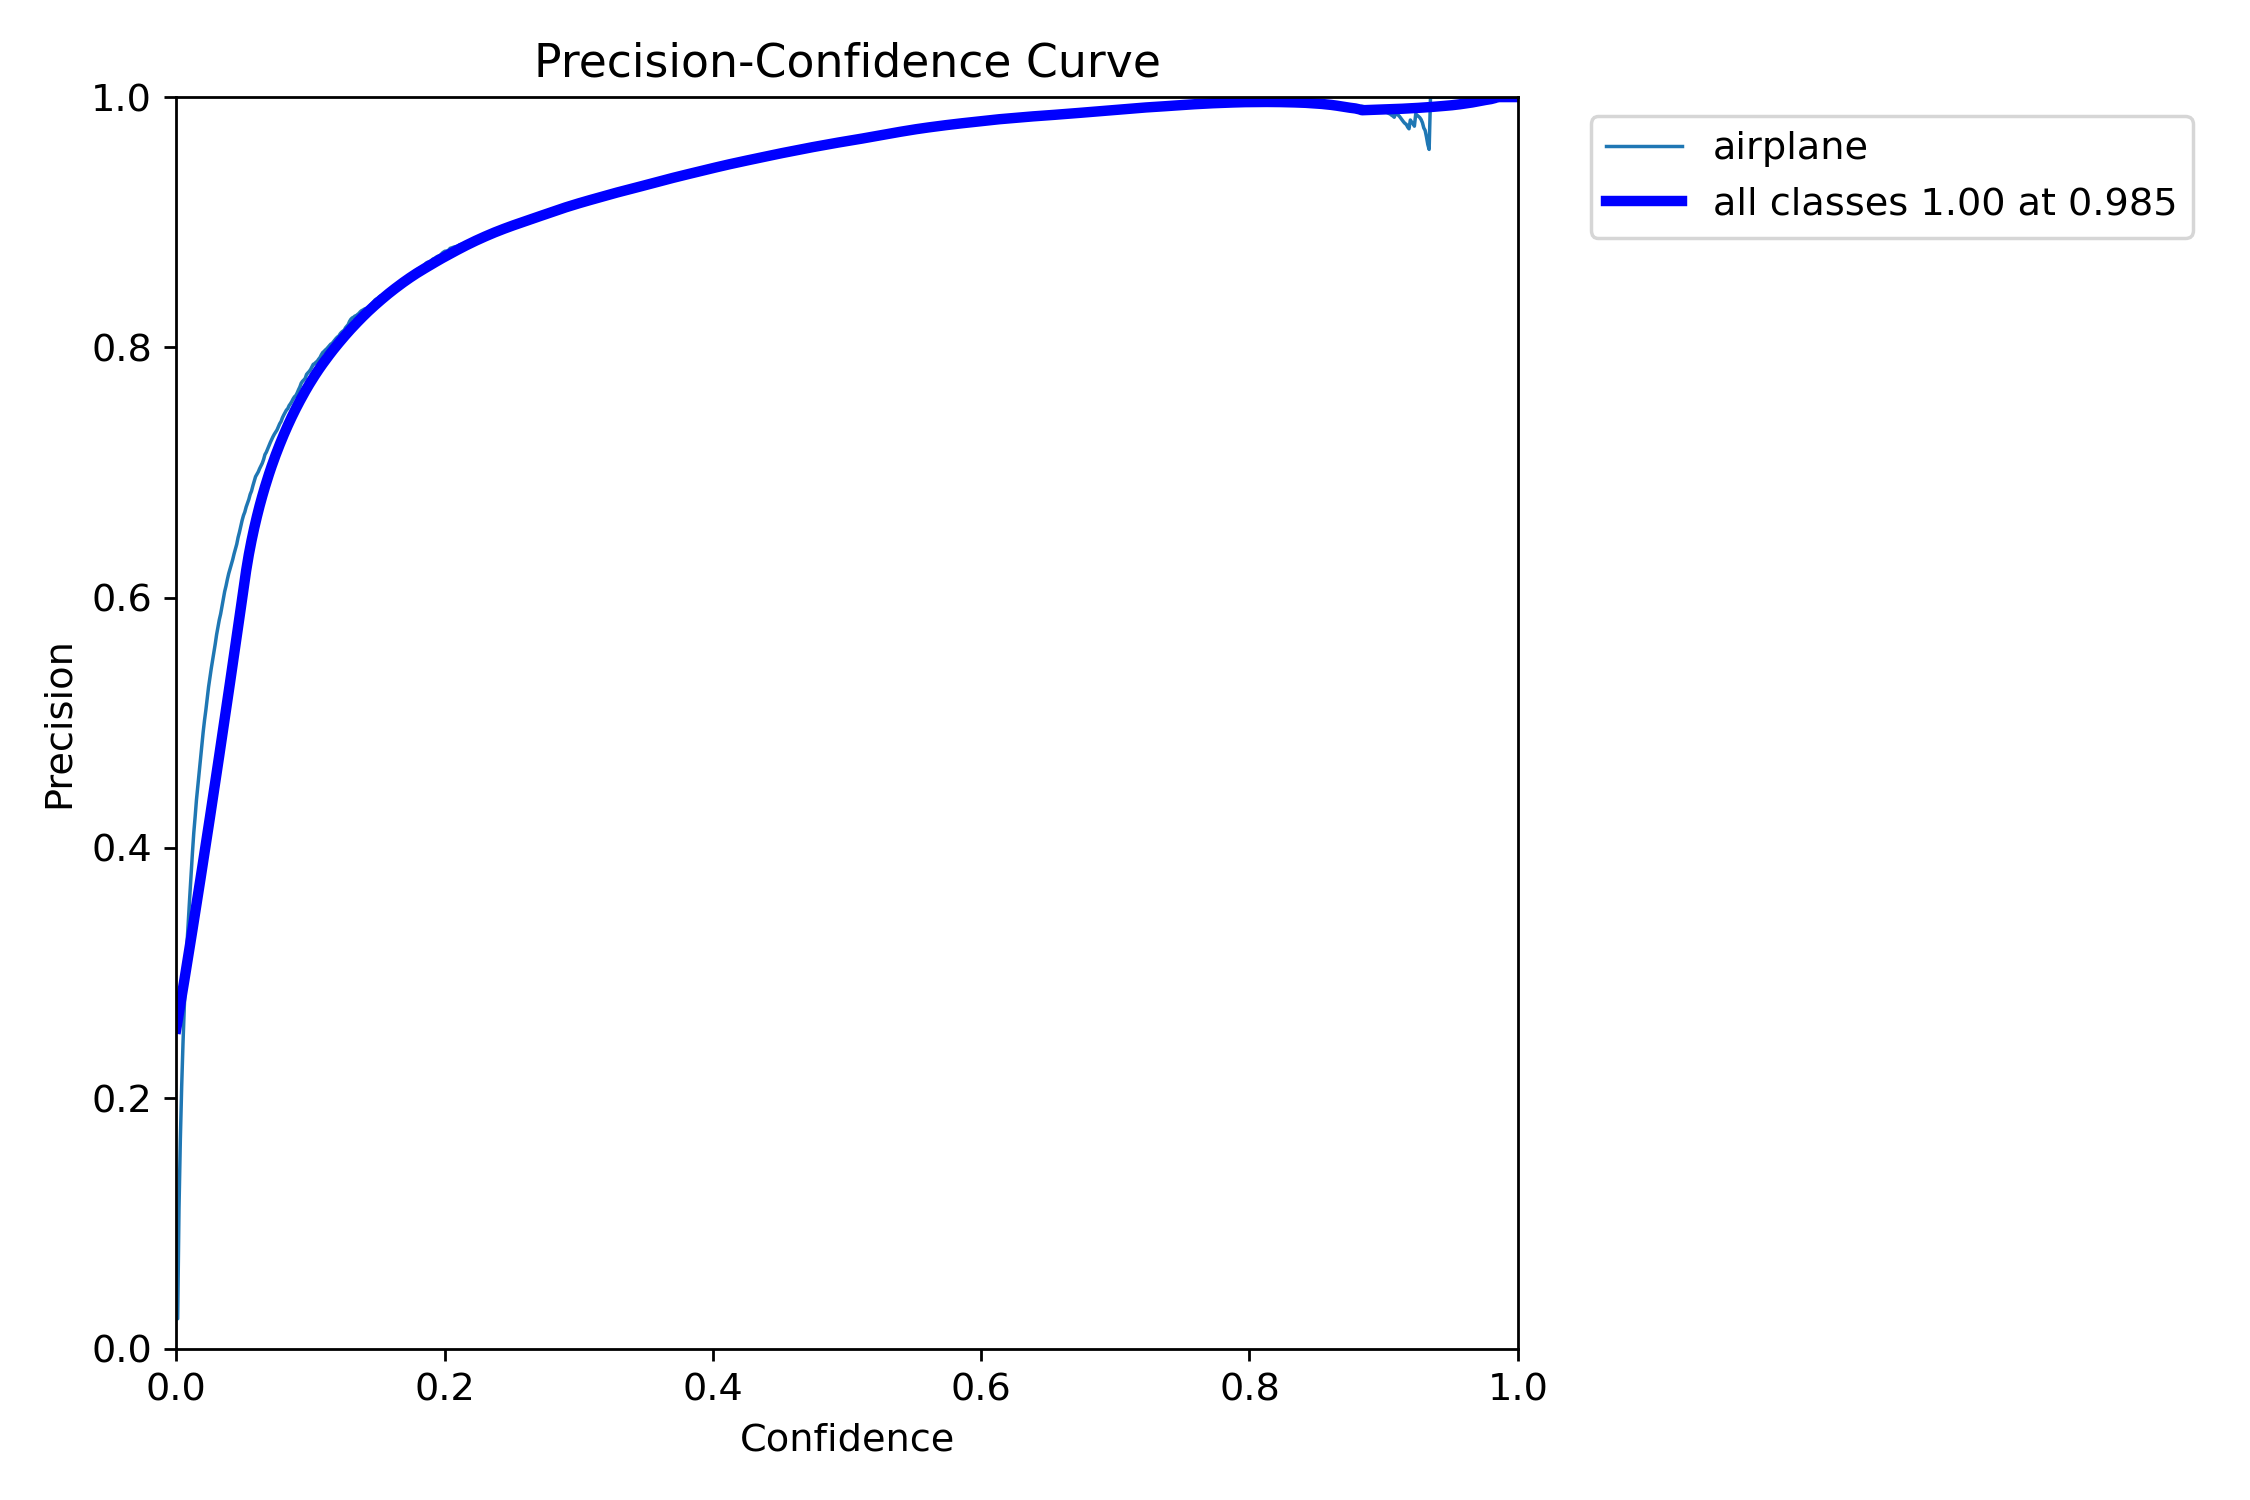

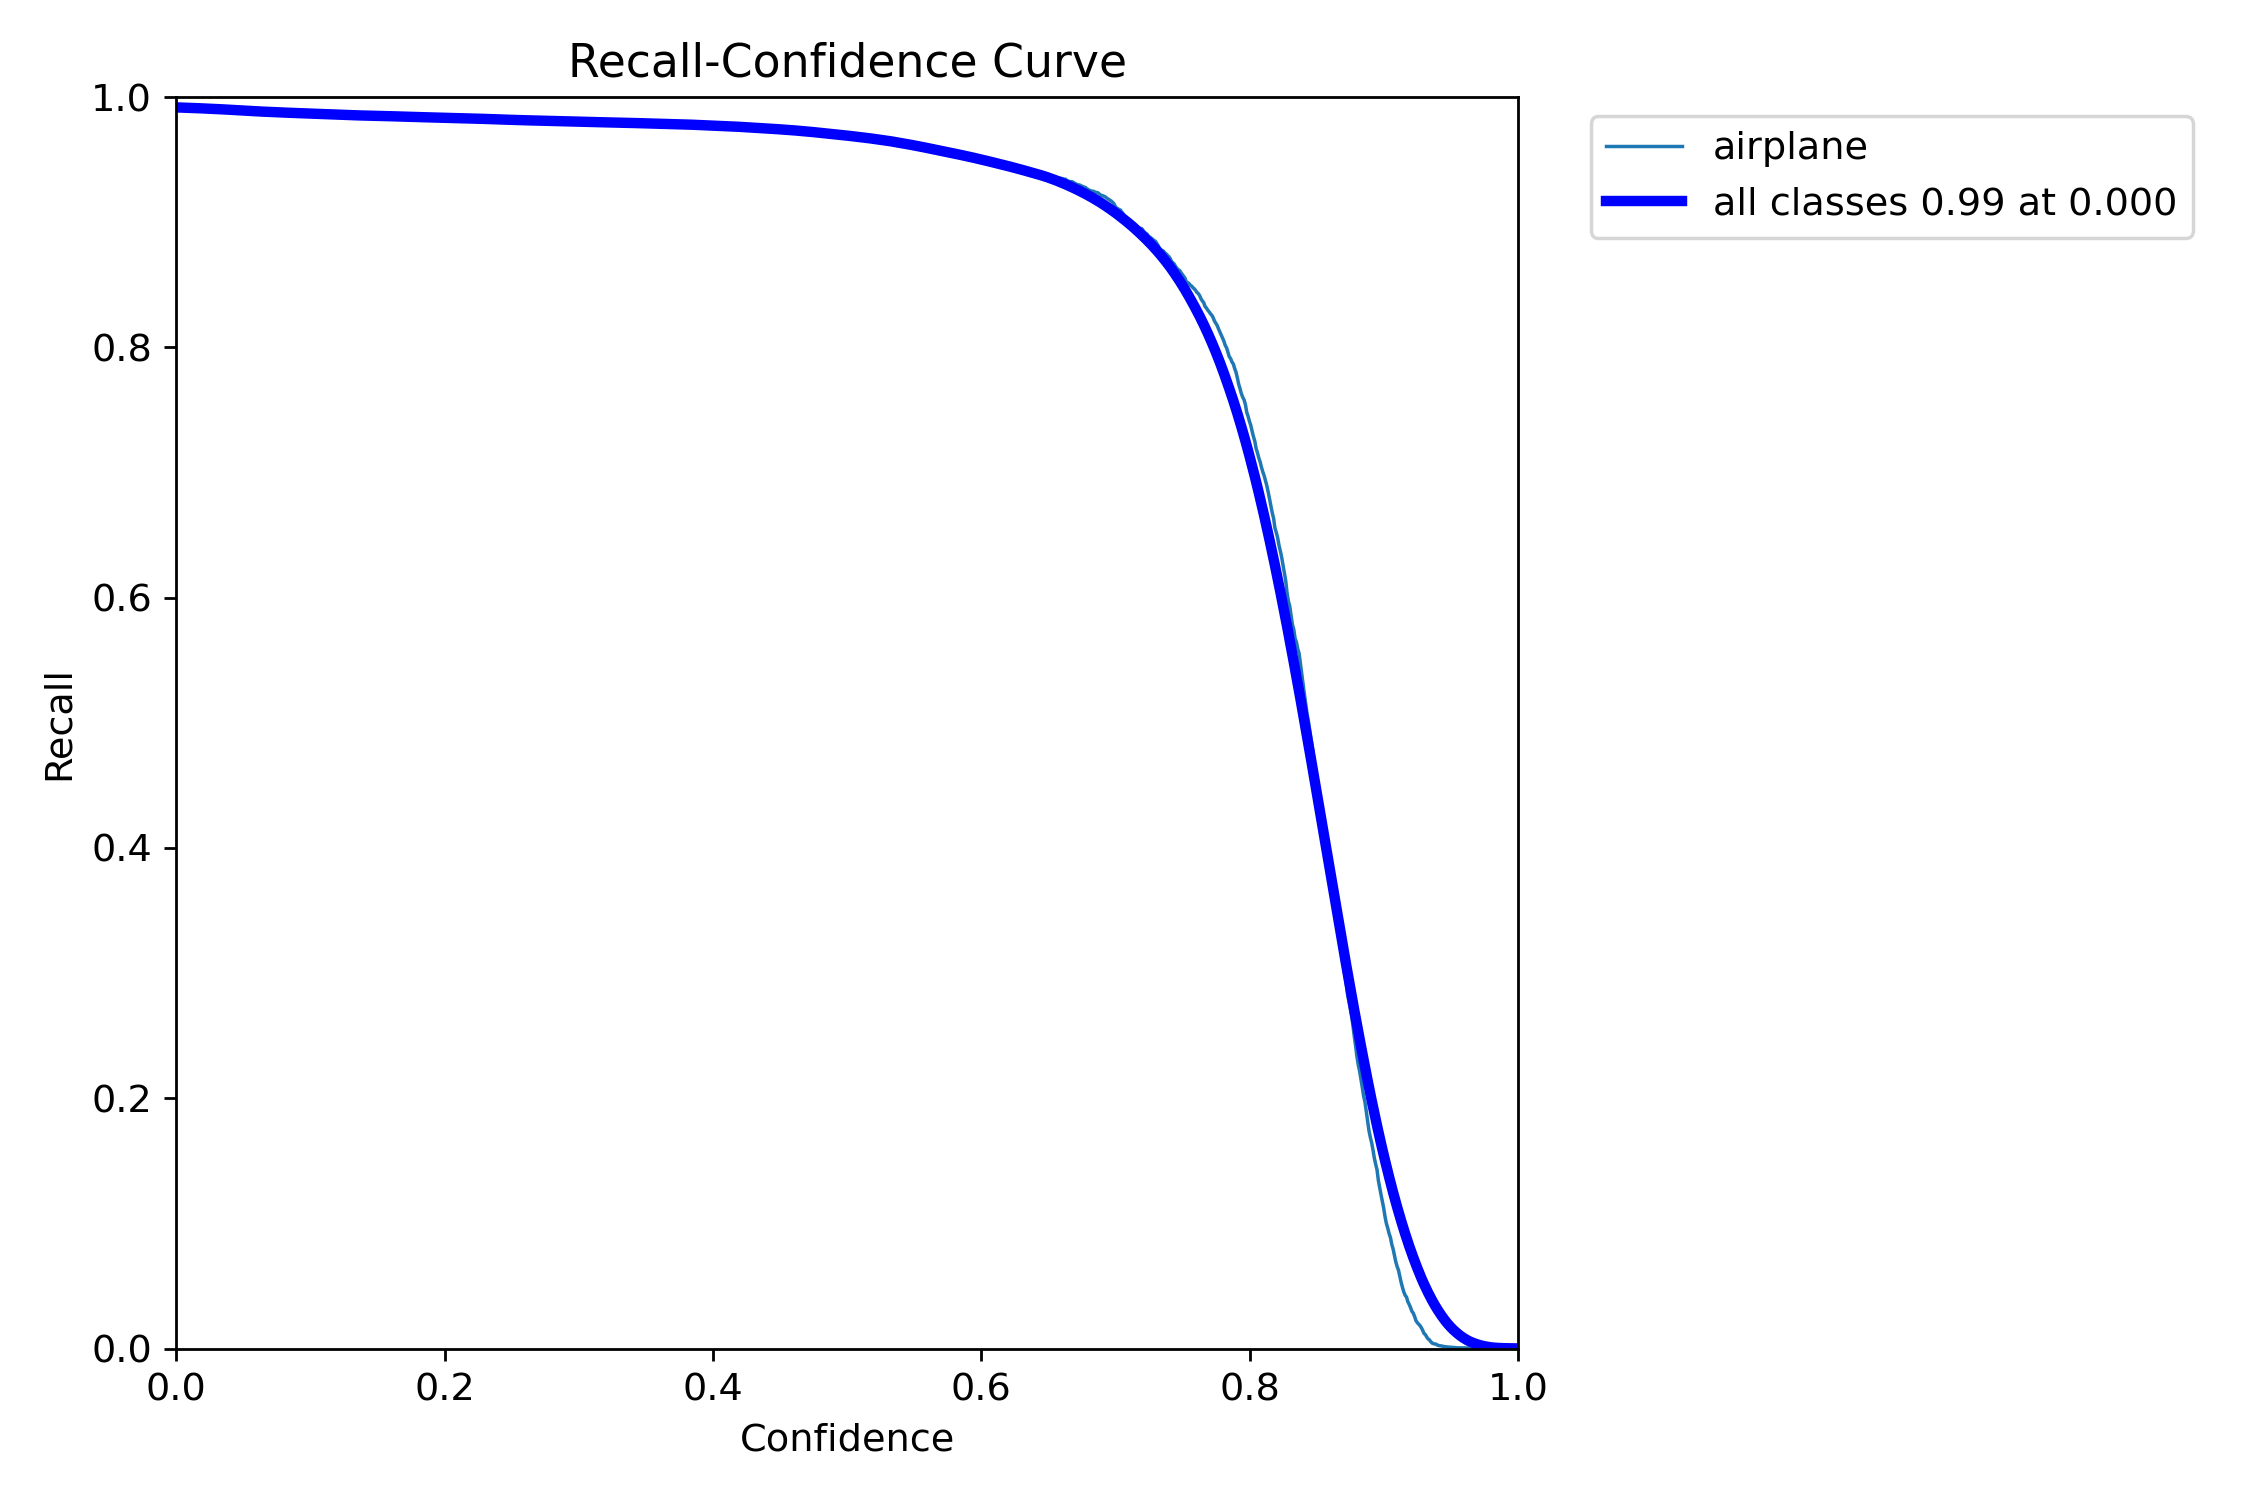

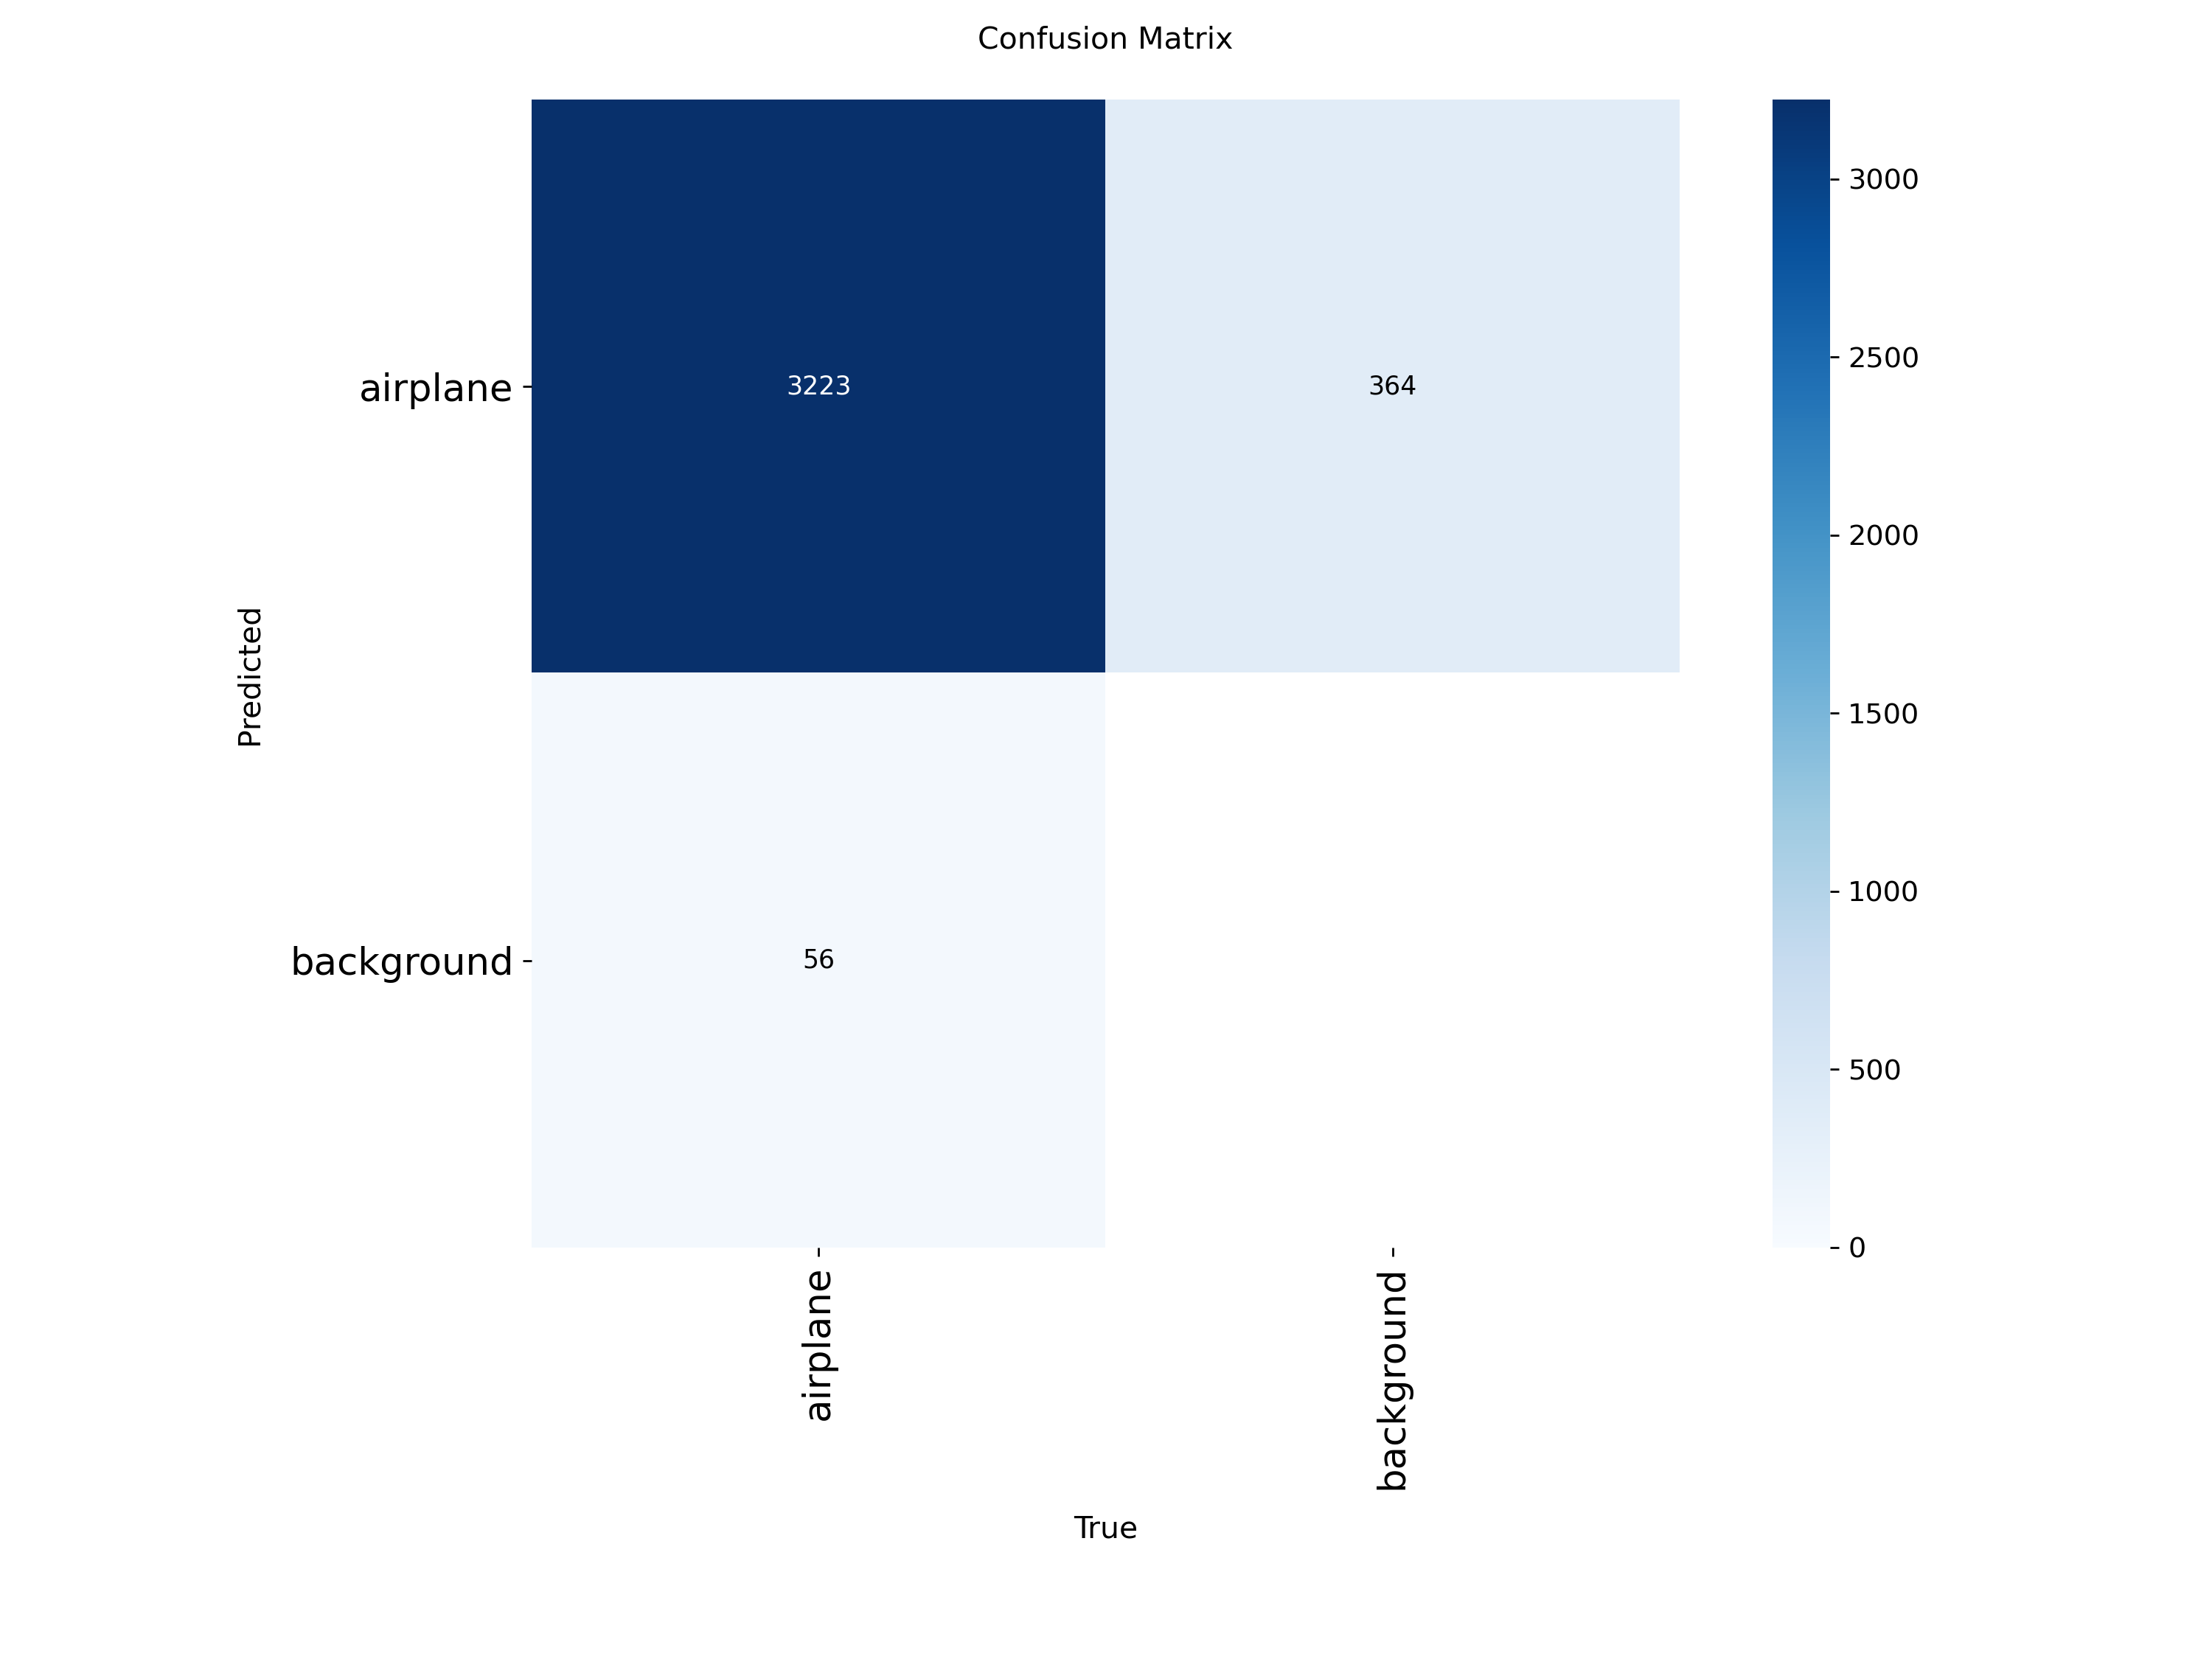

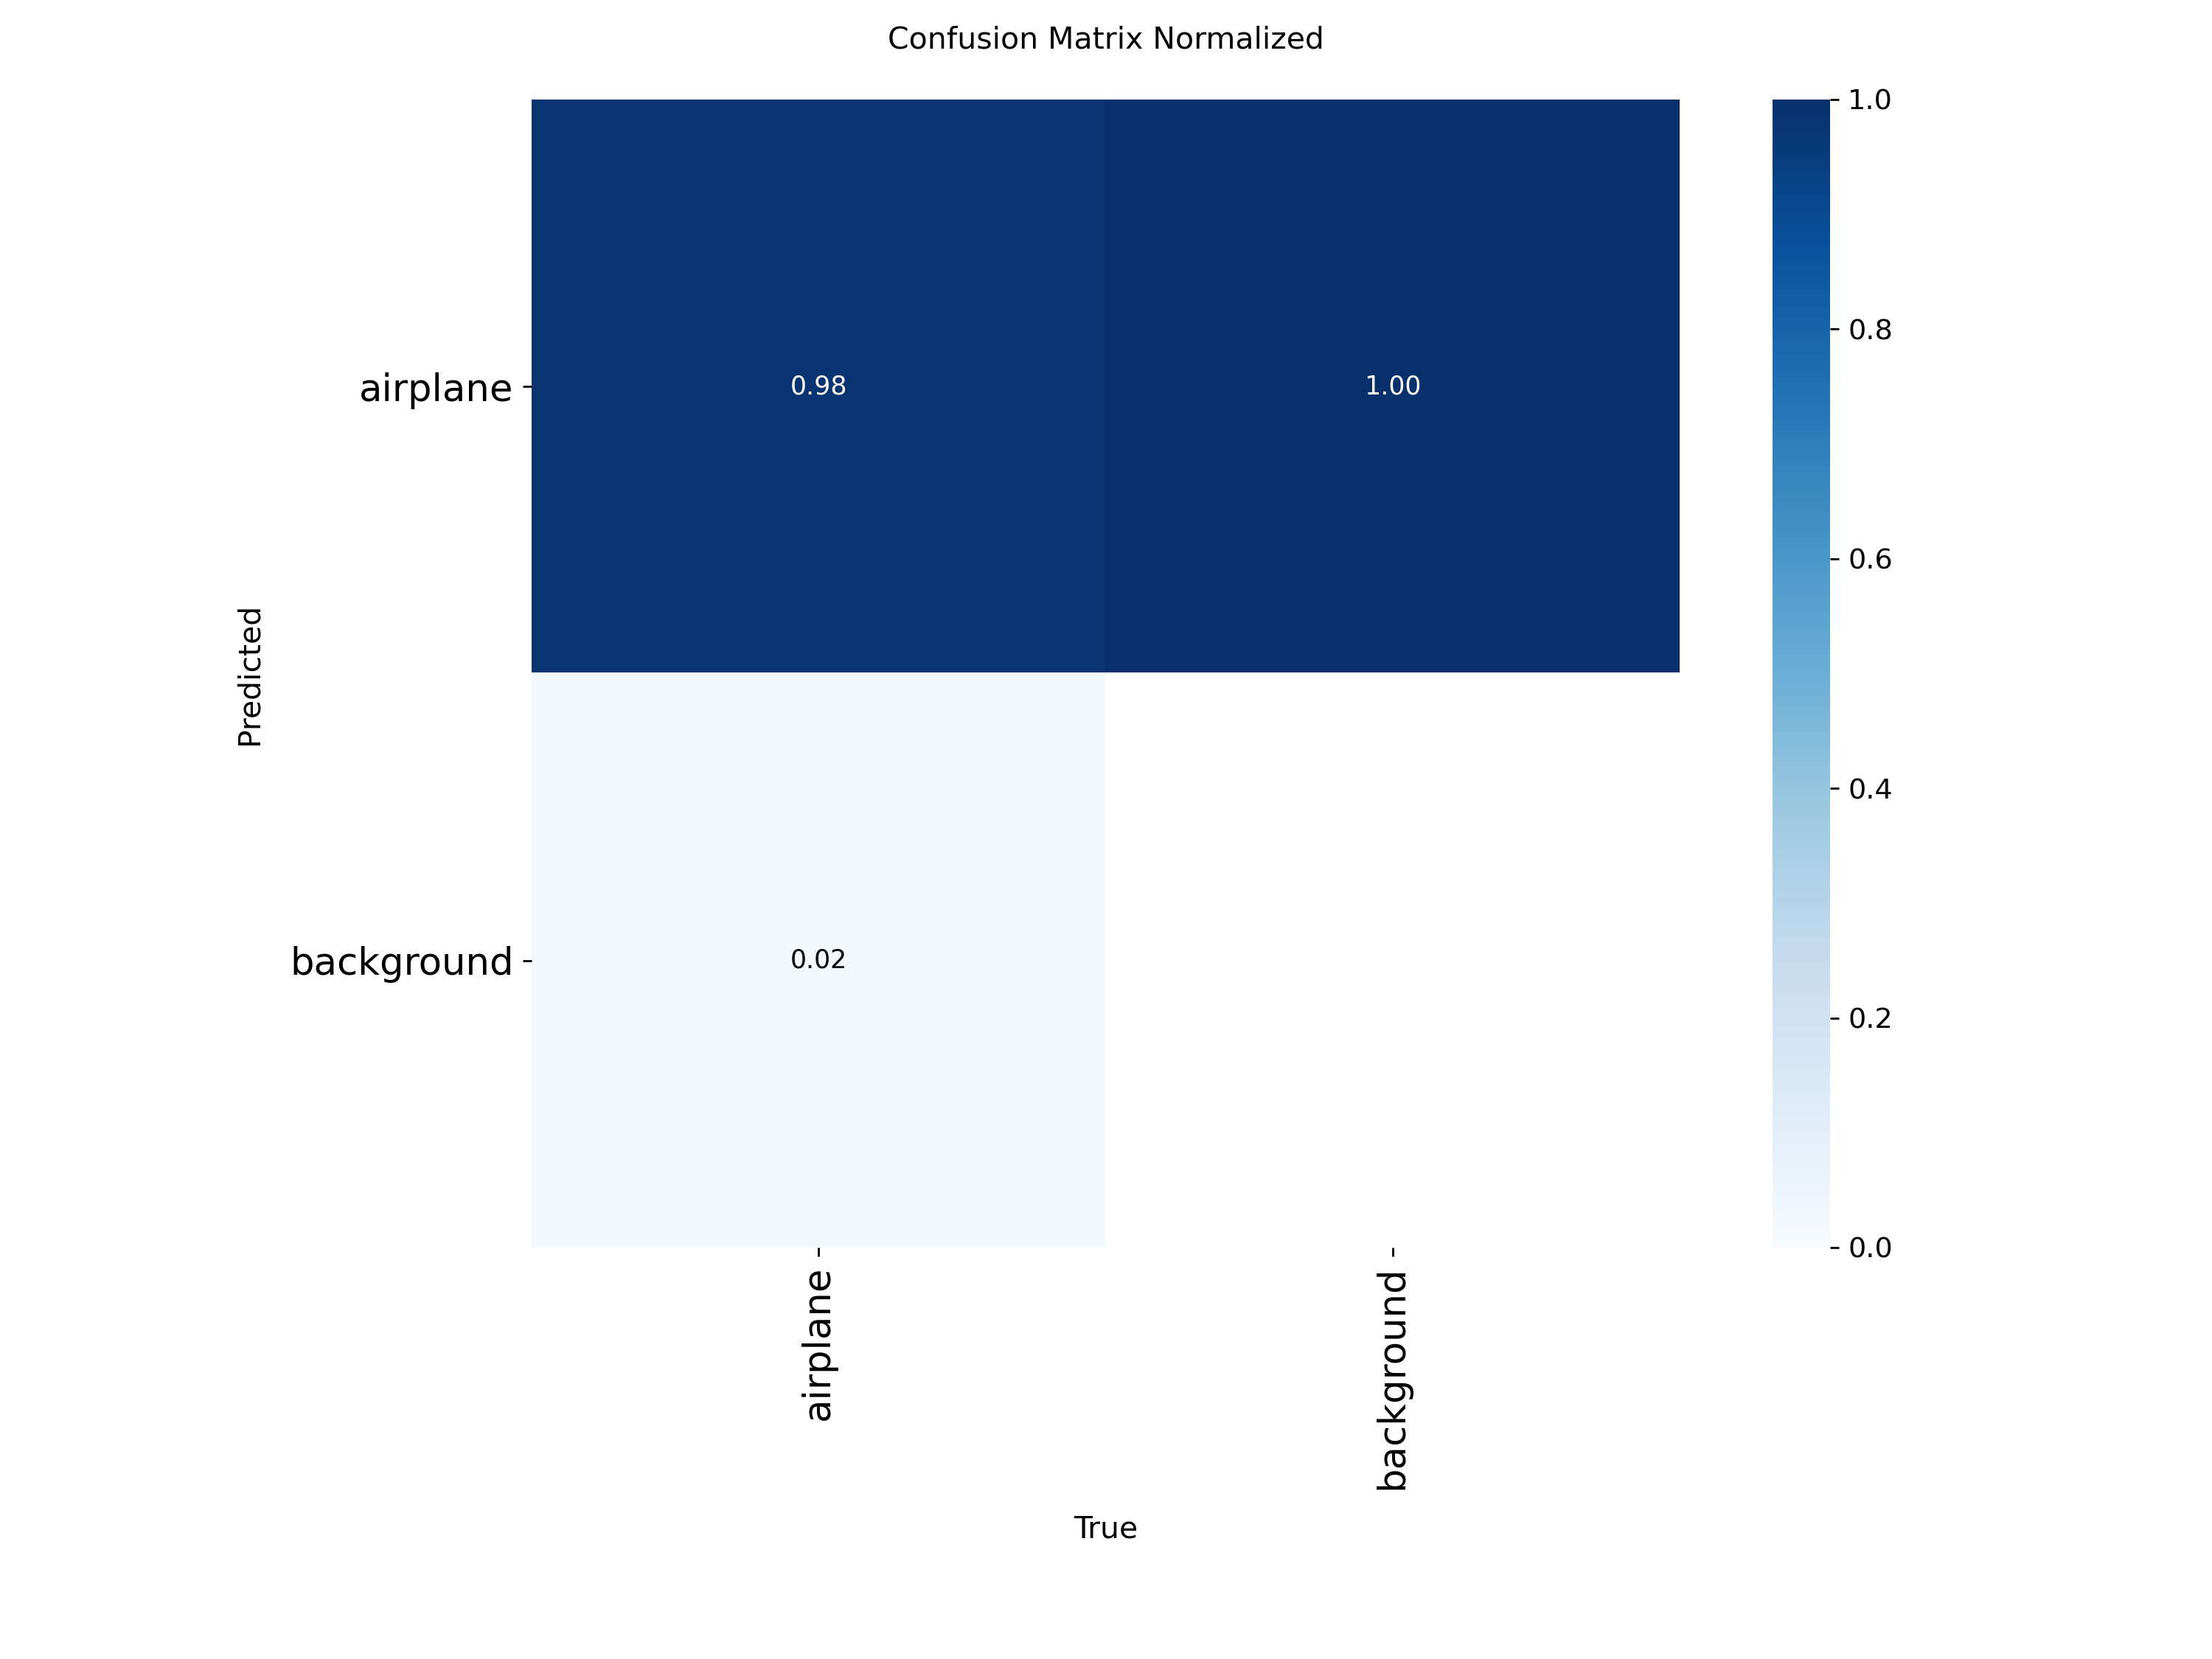

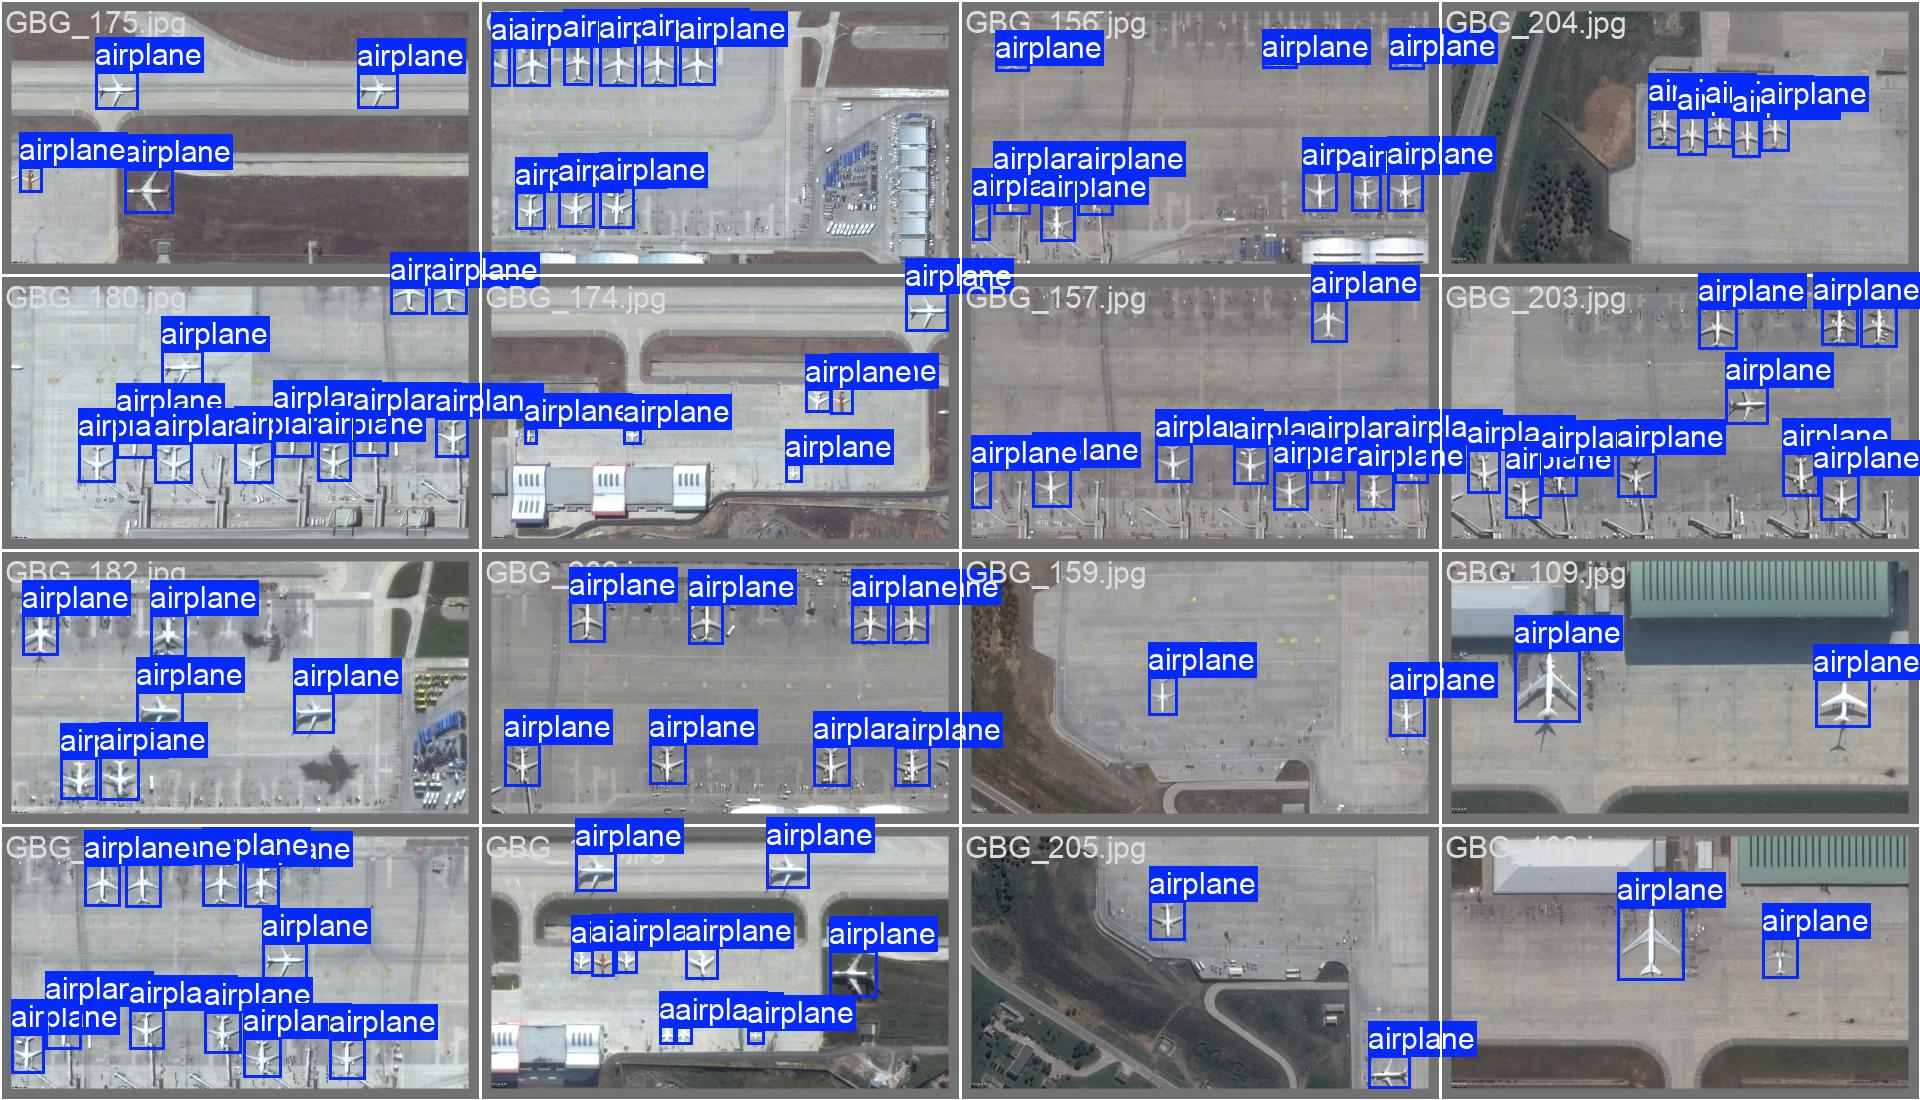

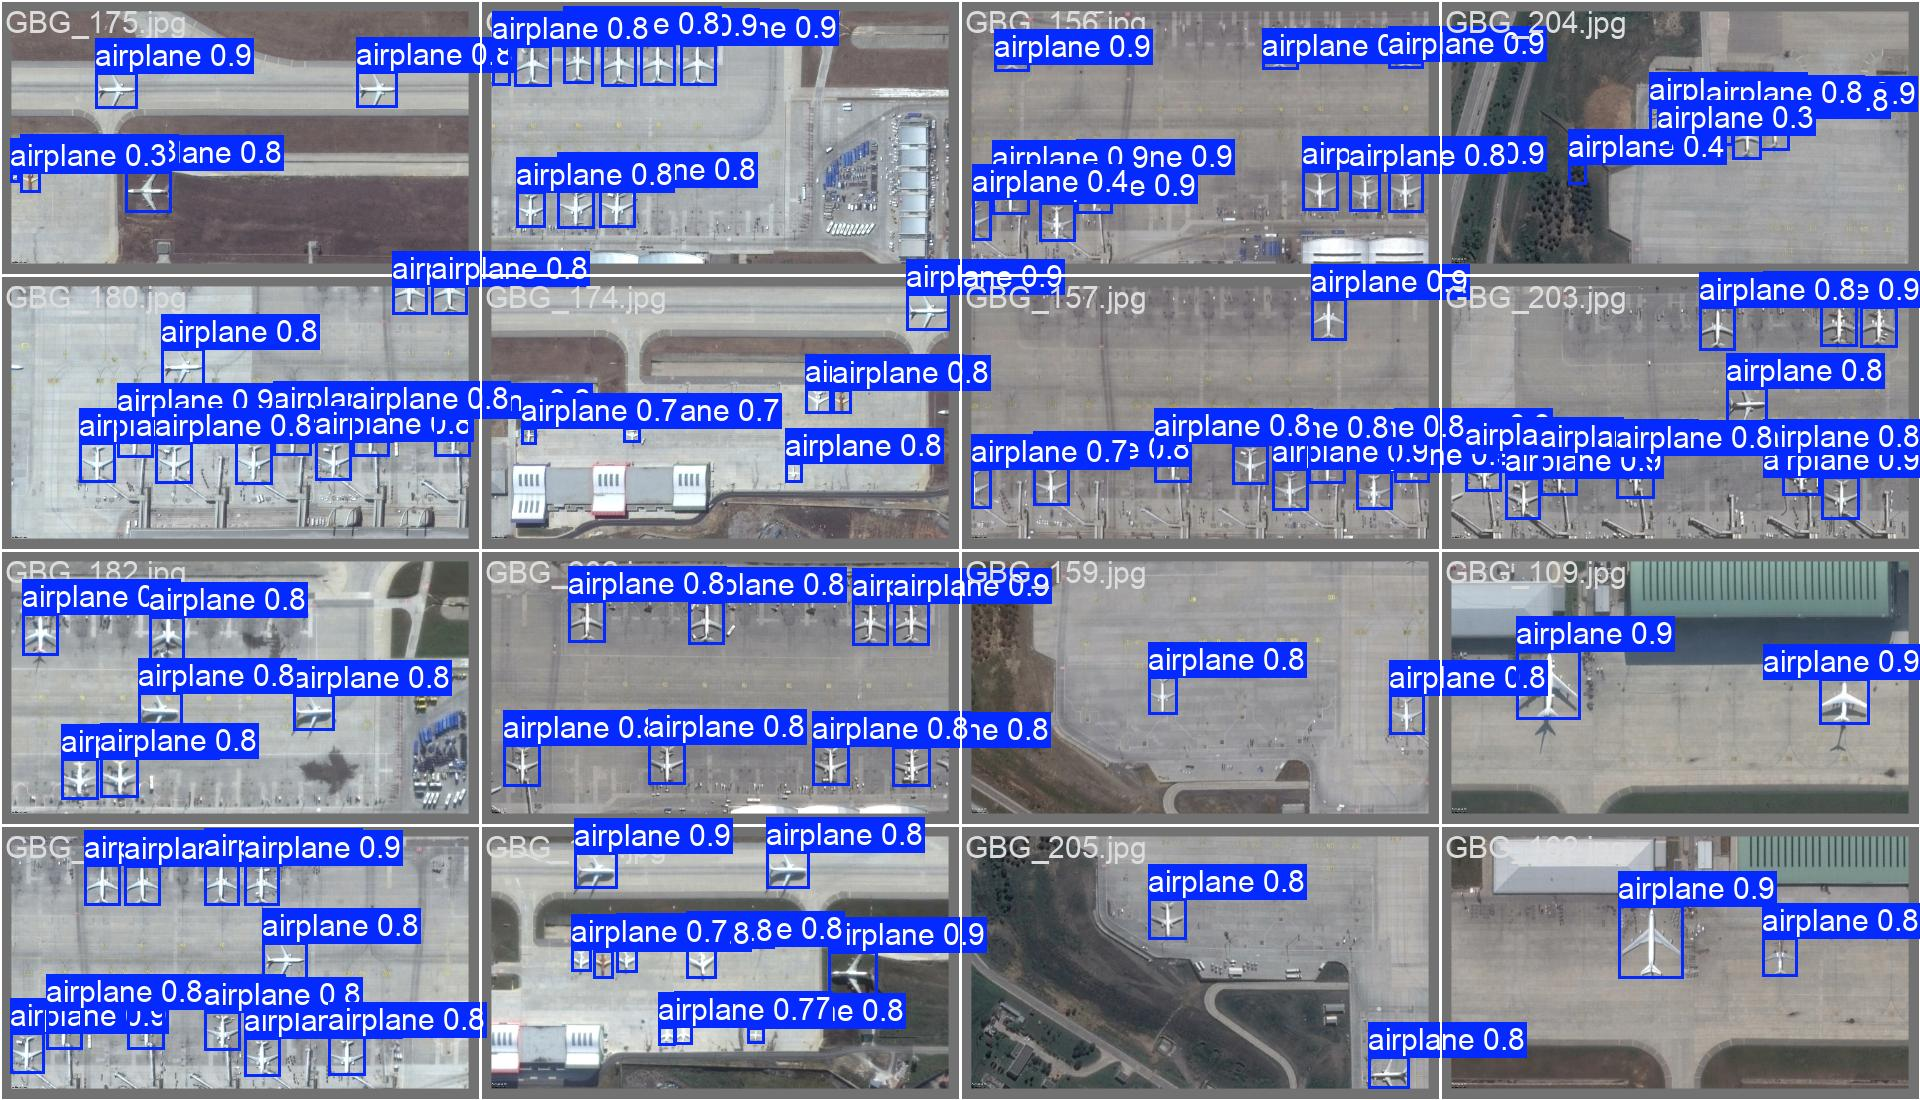

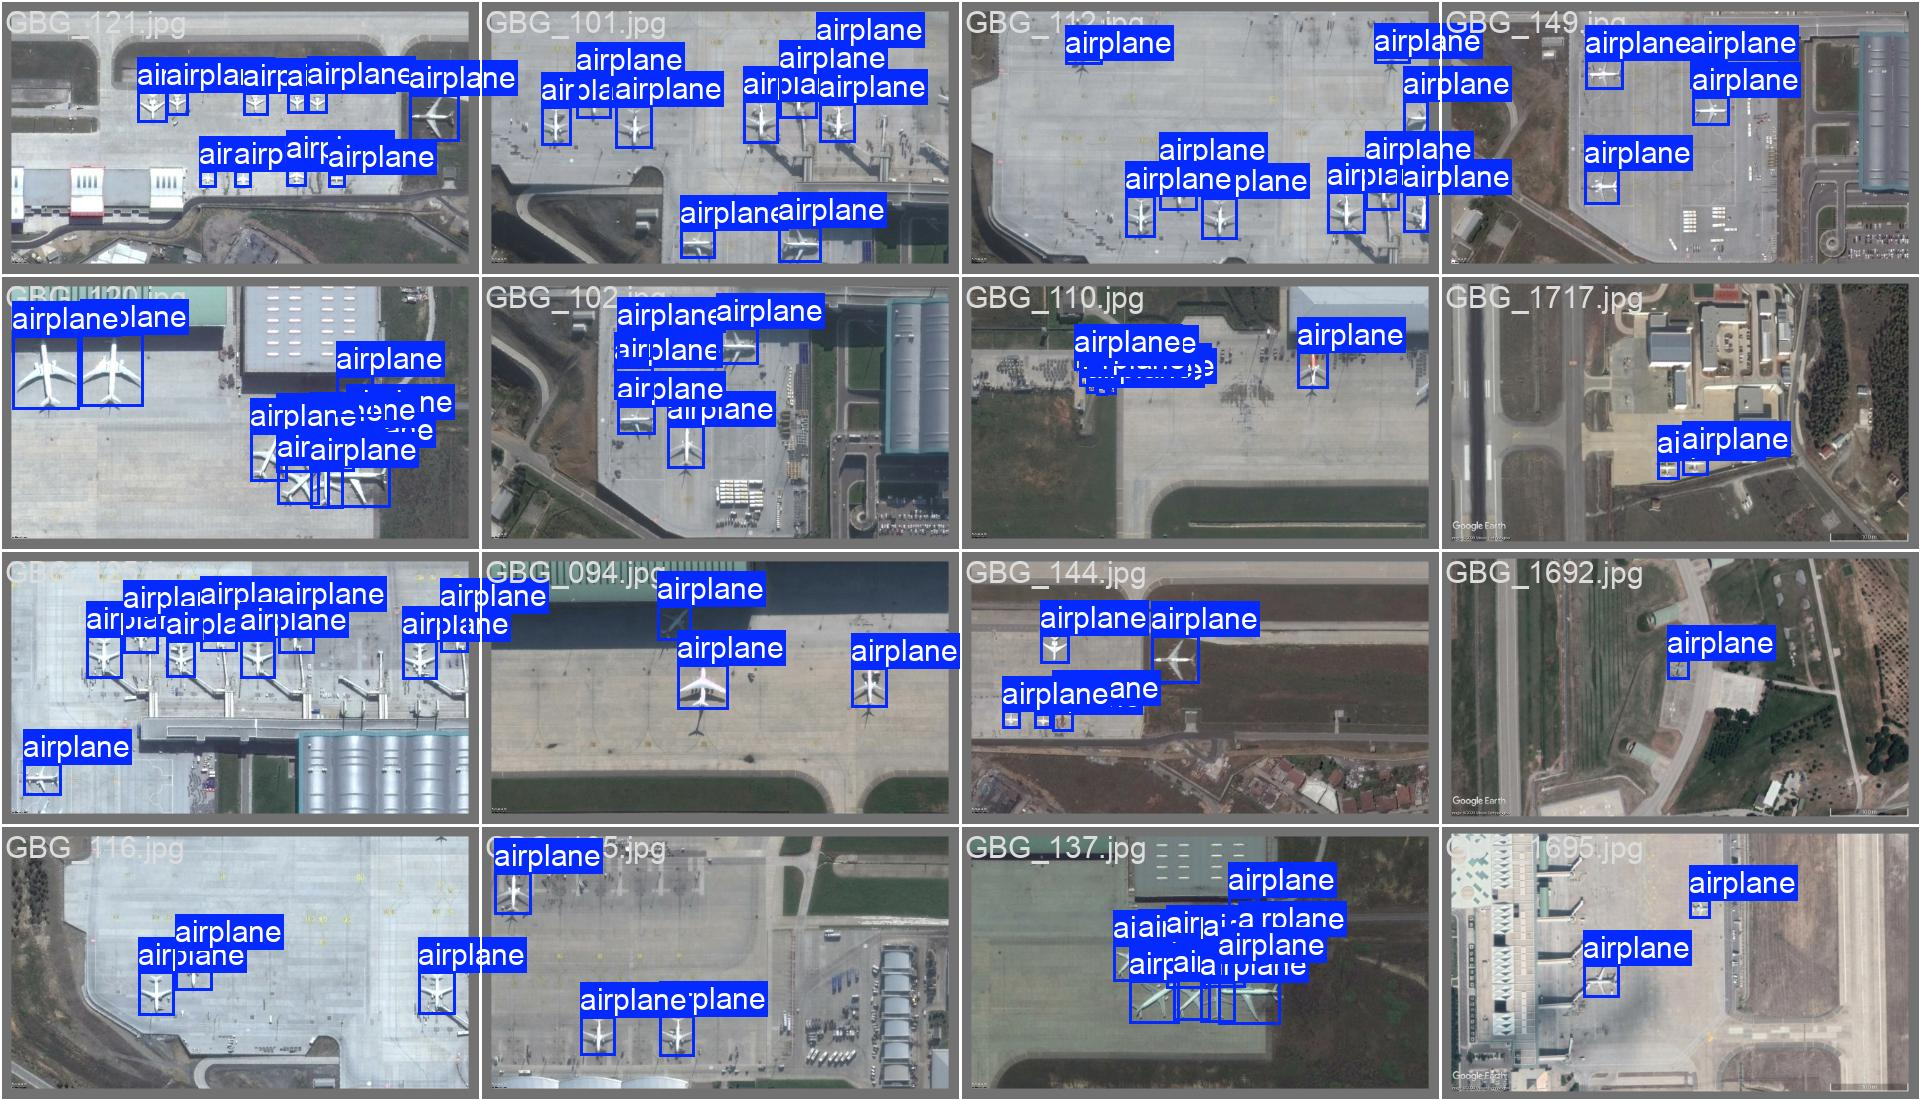

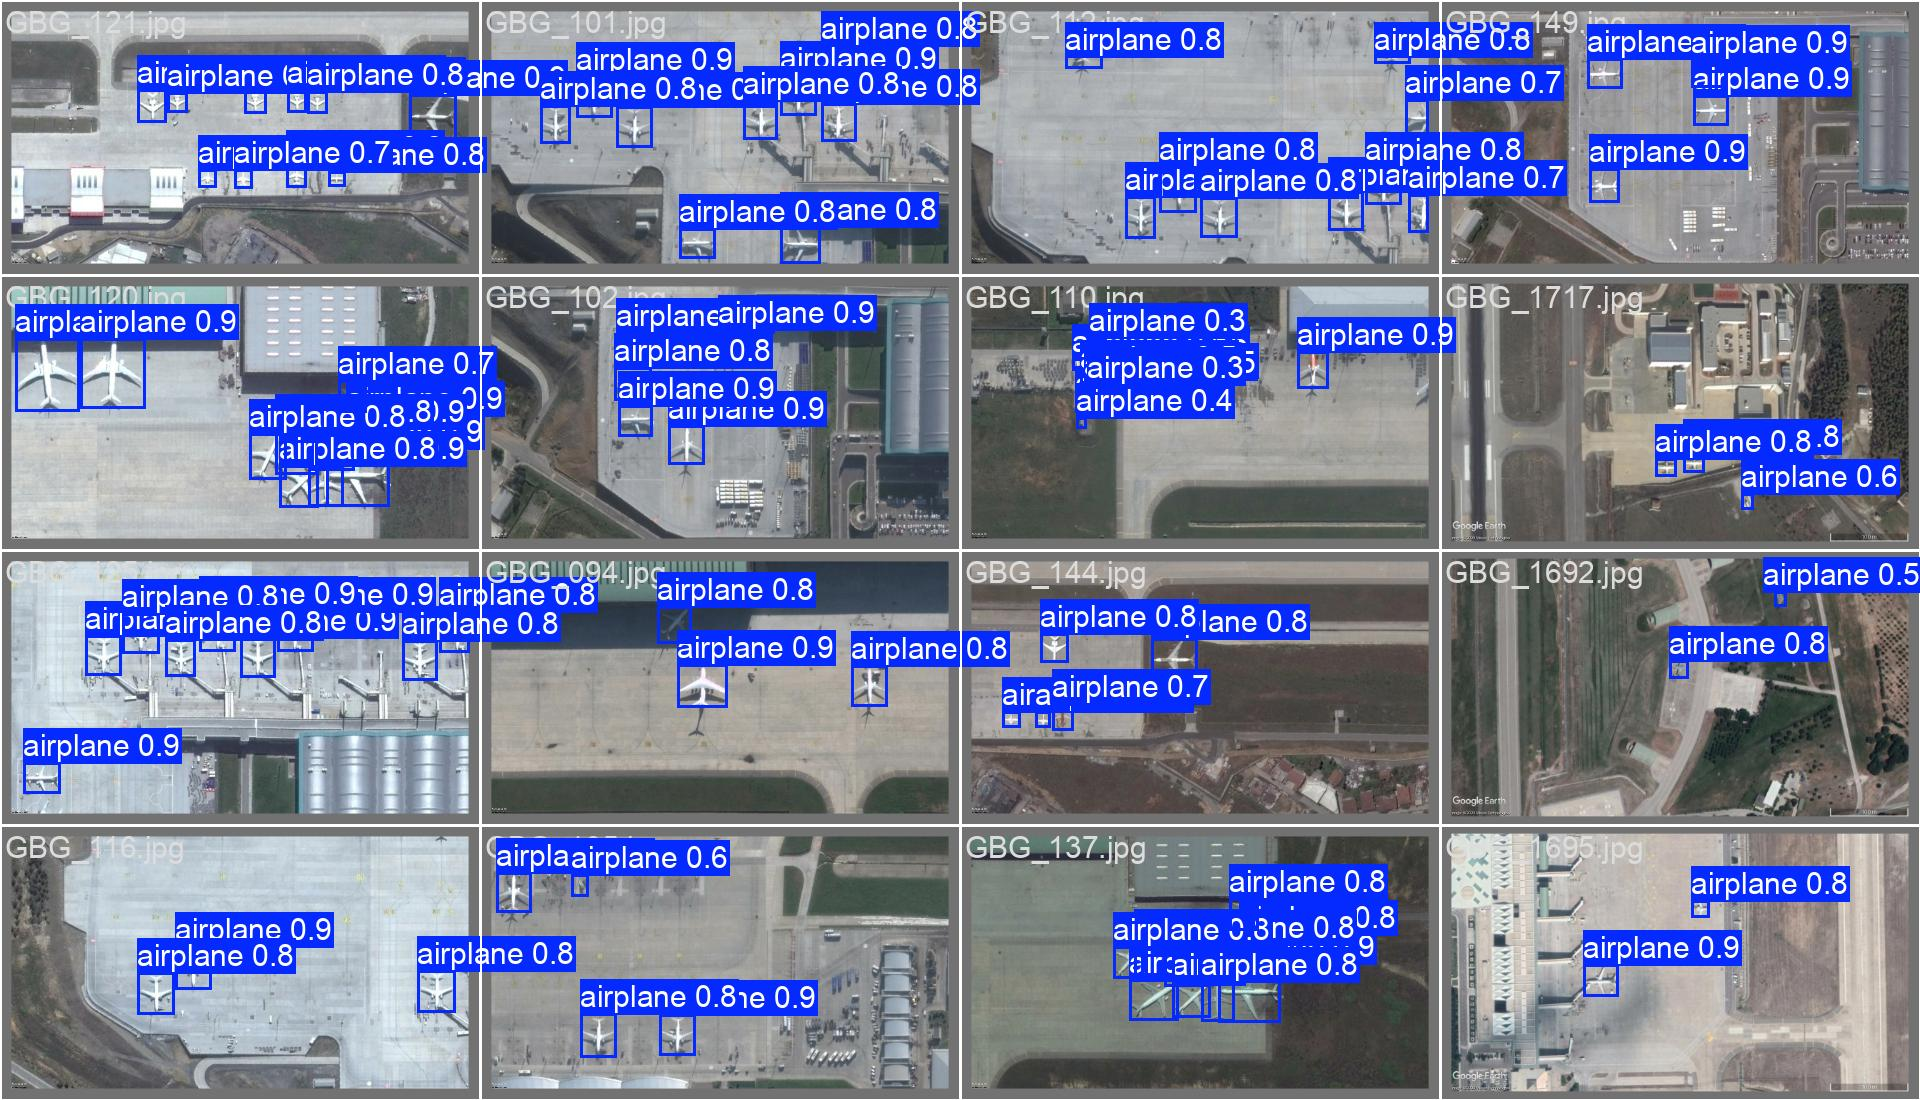

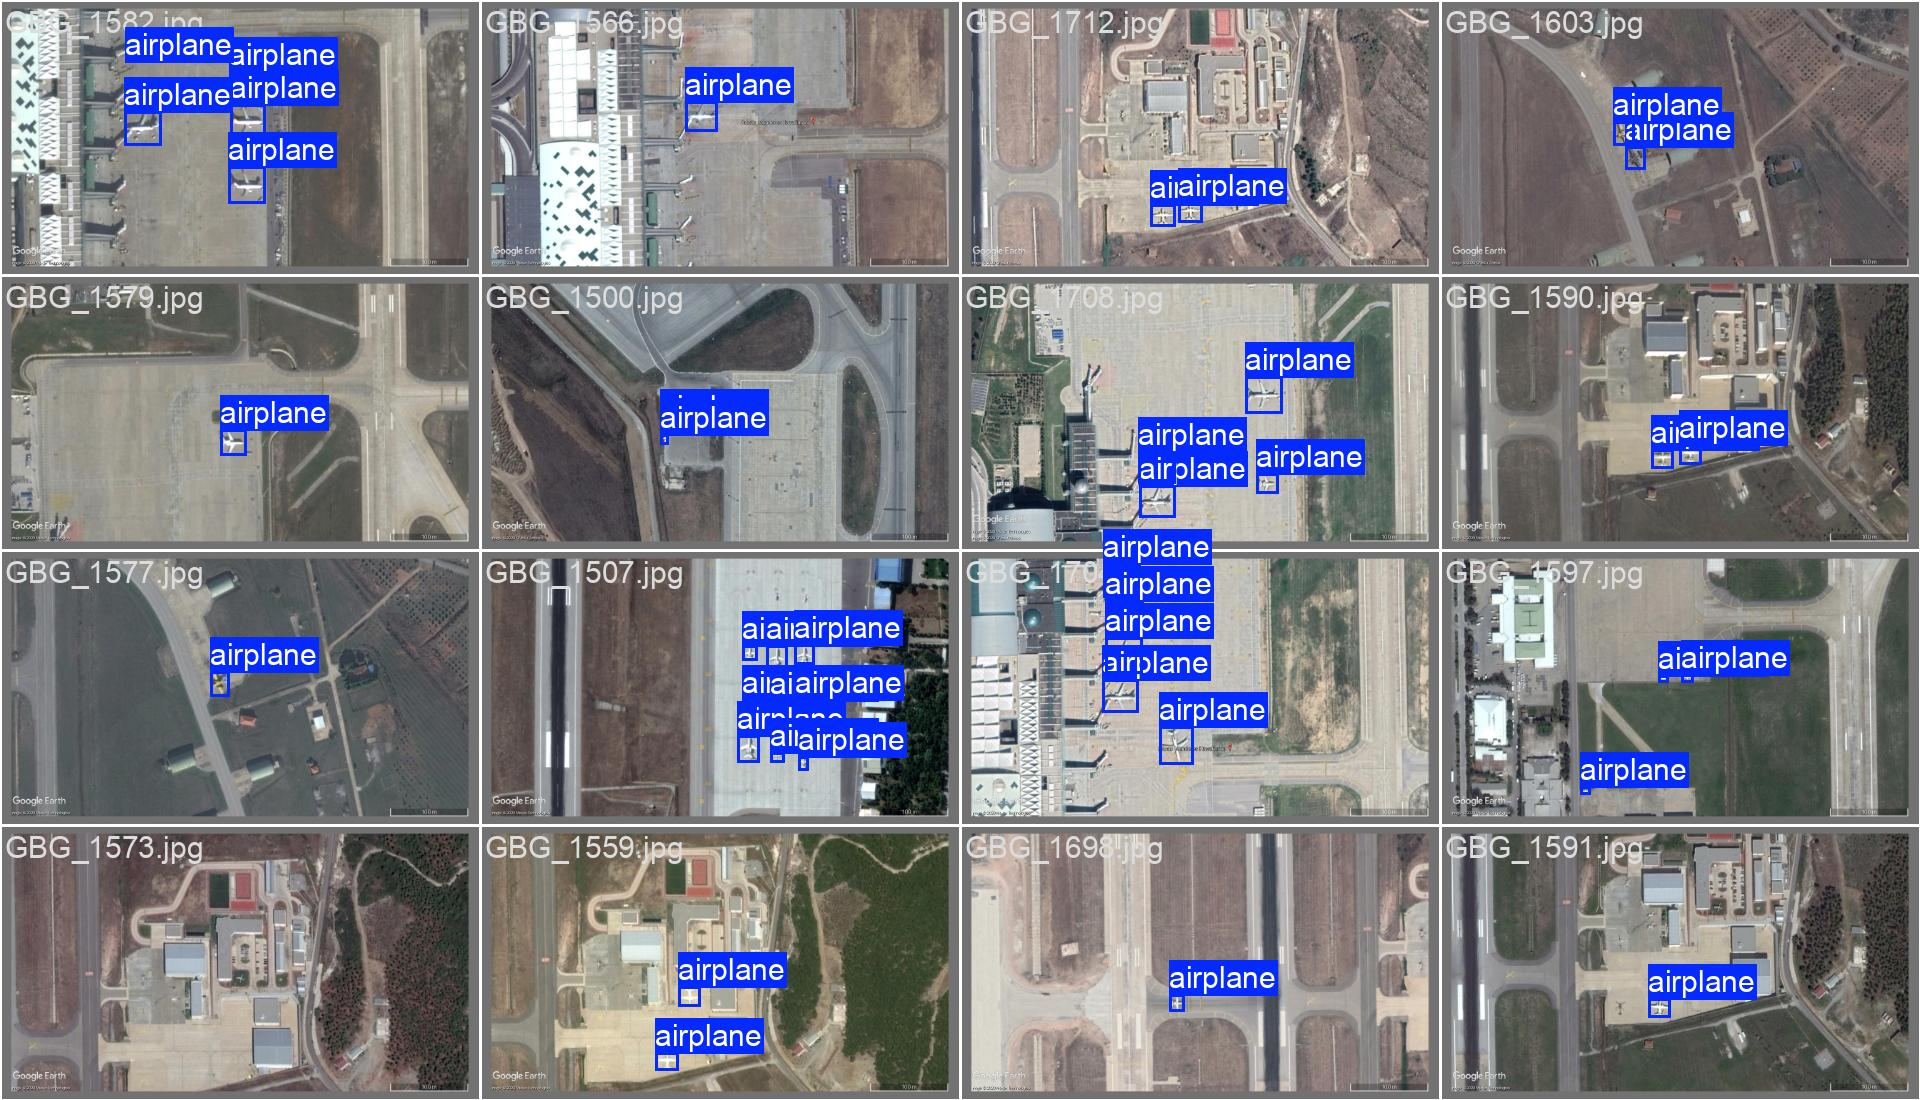

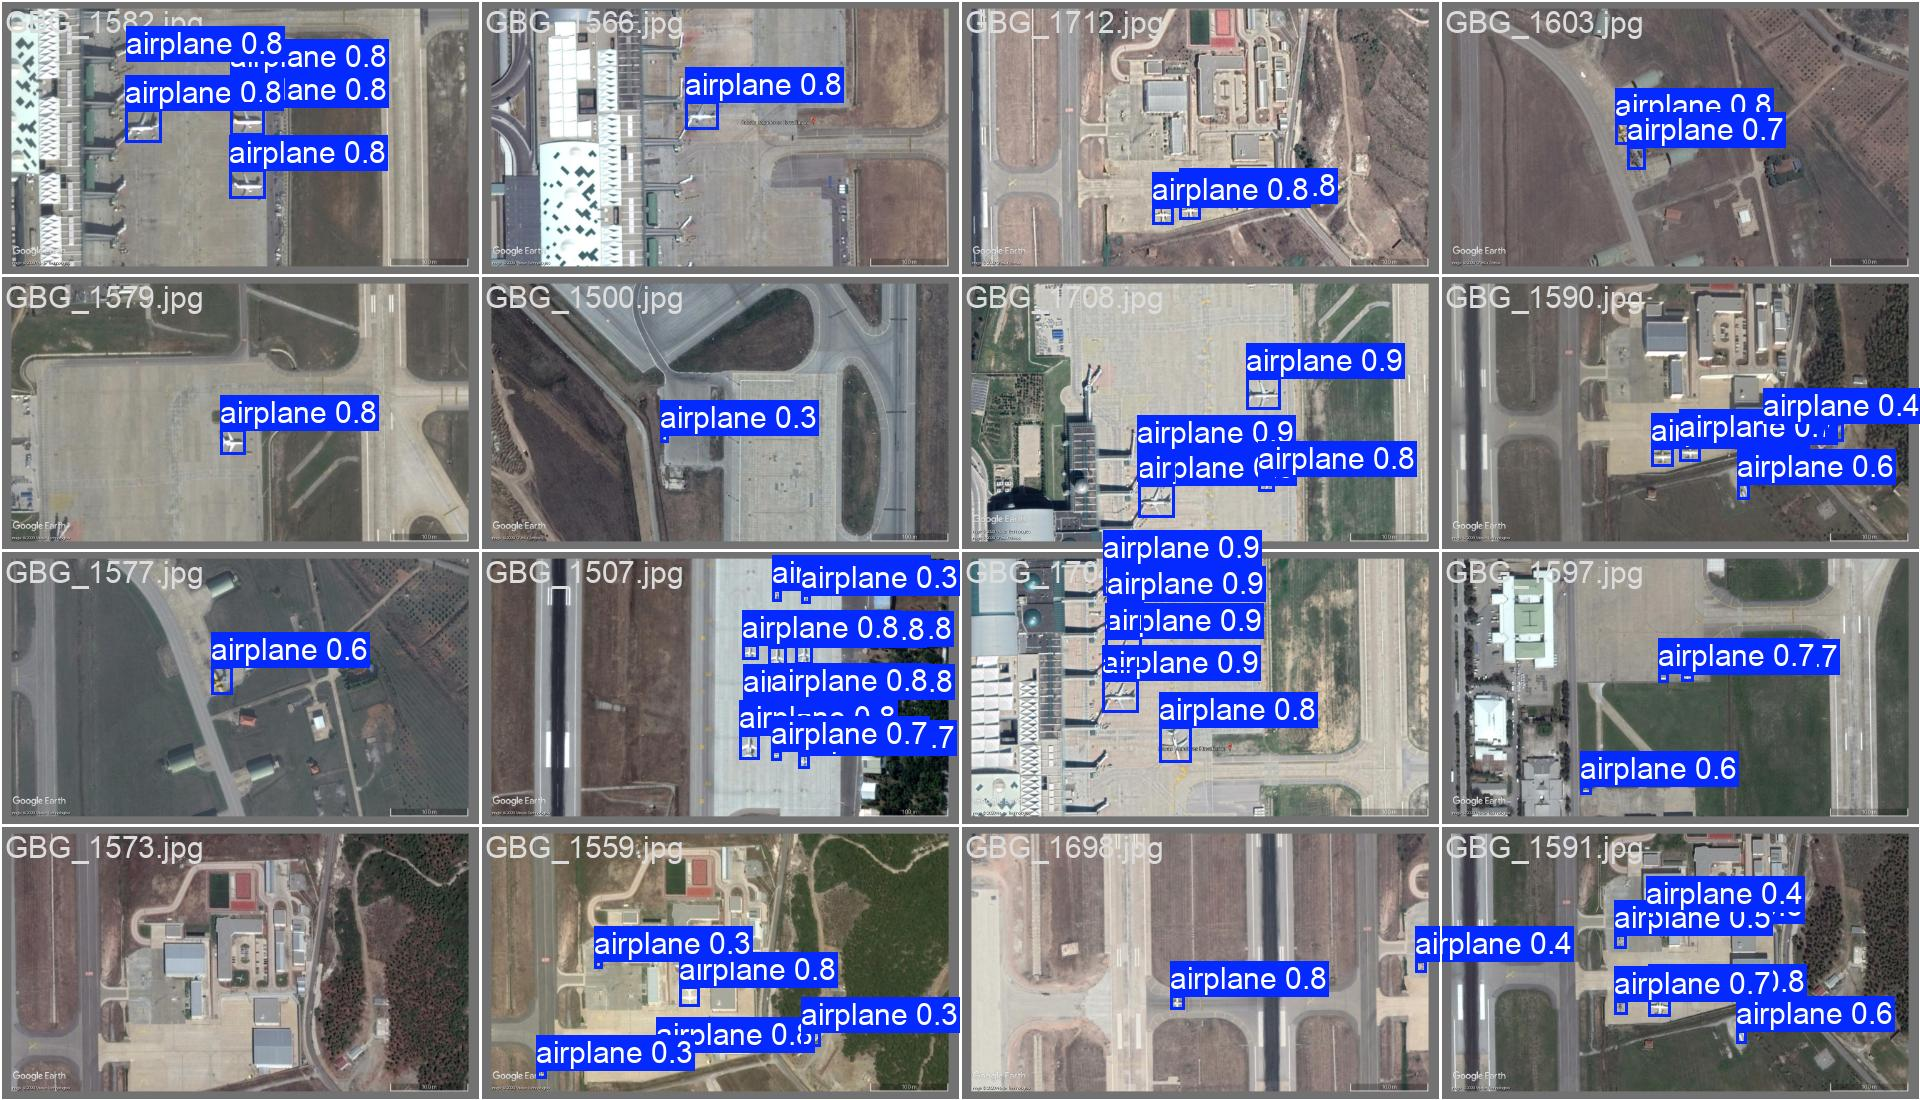

In [11]:
from IPython.display import Image, display
import glob
import os

for img_path in sorted(glob.glob('runs/detect/val/*.[pj][pn]g')):
    display(Image(filename=img_path))